# Twin experiments — HDI evolution (Figure 8)

Per-generation Highest Density Interval (HDI 95%) of the best individuals
for each parameter and experiment (Manuscript Figure 8, Section 3.4.2).

The HDI is normalised by the optimisation bound width (Table 1) so panels
are directly comparable.

Inputs: `data/ga_logbook_{STATION}_{MODE}.parquet`, `parameters.yaml`.
Output: `figures/Figure_8.{pdf,png}`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml


def _project_root(marker: str = "pyproject.toml") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root marker {marker!r} not found.")


PROJECT_ROOT = _project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(PROJECT_ROOT / "parameters.yaml") as f:
    PARAMS = yaml.safe_load(f)
BOUNDS = PARAMS["model_parameters"]["bounds"]
GA = PARAMS["genetic_algorithm"]
mode = GA["mode"]
experiments = GA["experiments"]

DISPLAY = {"BARENTS": "BARENTS", "PAPA": "PAPA", "Bay_of_Biscay": "BISCAY",
           "BATS": "BATS", "Canaries": "CANARY", "HOT": "HOT", "MERGED": "MERGED"}
PARAM_ORDER = ["energy_transfert", "tr_0", "gamma_tr", "lambda_temperature_0", "gamma_lambda_temperature"]
PARAM_LABELS = {
    "energy_transfert": r"$E$",
    "tr_0": r"$\tau_{r_0}$",
    "gamma_tr": r"$\gamma_{\tau_r}$",
    "lambda_temperature_0": r"$\lambda_0$",
    "gamma_lambda_temperature": r"$\gamma_\lambda$",
}
M_BEST = 1000   # cap; production mode uses 1000, test mode caps to what is available
HDI_LEVEL = 0.95

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

## HDI of the top-M individuals per generation, normalised by parameter range

In [2]:
def _hdi(samples: np.ndarray, level: float = HDI_LEVEL) -> tuple[float, float]:
    s = np.sort(samples)
    n = len(s)
    k = int(np.floor(level * n))
    if k == n:
        return float(s[0]), float(s[-1])
    widths = s[k:] - s[: n - k]
    i = int(np.argmin(widths))
    return float(s[i]), float(s[i + k])


def _normalised_hdi(df: pd.DataFrame, m_best: int) -> pd.DataFrame:
    rows = []
    for gen, gen_df in df.groupby(level="Generation"):
        ranked = gen_df.sort_values(("Weighted_fitness", "Weighted_fitness"), ascending=False)
        top = ranked.head(min(m_best, len(ranked)))
        row = {"Generation": gen}
        for param in PARAM_ORDER:
            samples = top[("Parametre", param)].values
            if len(samples) < 2:
                row[param] = np.nan
            else:
                lo, hi = _hdi(samples)
                lo_bound, hi_bound = BOUNDS[param]
                row[param] = (hi - lo) / (hi_bound - lo_bound)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Generation")


hdi_by_exp = {}
for sid in experiments:
    df = pd.read_parquet(DATA_DIR / f"ga_logbook_{sid}_{mode}.parquet")
    hdi_by_exp[DISPLAY[sid]] = _normalised_hdi(df, M_BEST)

hdi_by_exp["MERGED"].head()

,energy_transfert,tr_0,gamma_tr,lambda_temperature_0,gamma_lambda_temperature
Generation,,,,,
0,0.940960,0.938033,0.934631,0.932415,0.938440
1,0.728628,0.953144,0.885390,0.898334,0.891284
2,0.730373,0.884209,0.792581,0.469841,0.880424
3,0.514078,0.659207,0.618174,0.158716,0.840015
4,0.530786,0.643458,0.569285,0.131190,0.757897


## Figure 8 — normalised HDI of best individuals per generation

/var/folders/3n/w67lcsm50xlfn4ky90v4s1dm0000gn/T/ipykernel_76034/1271475641.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


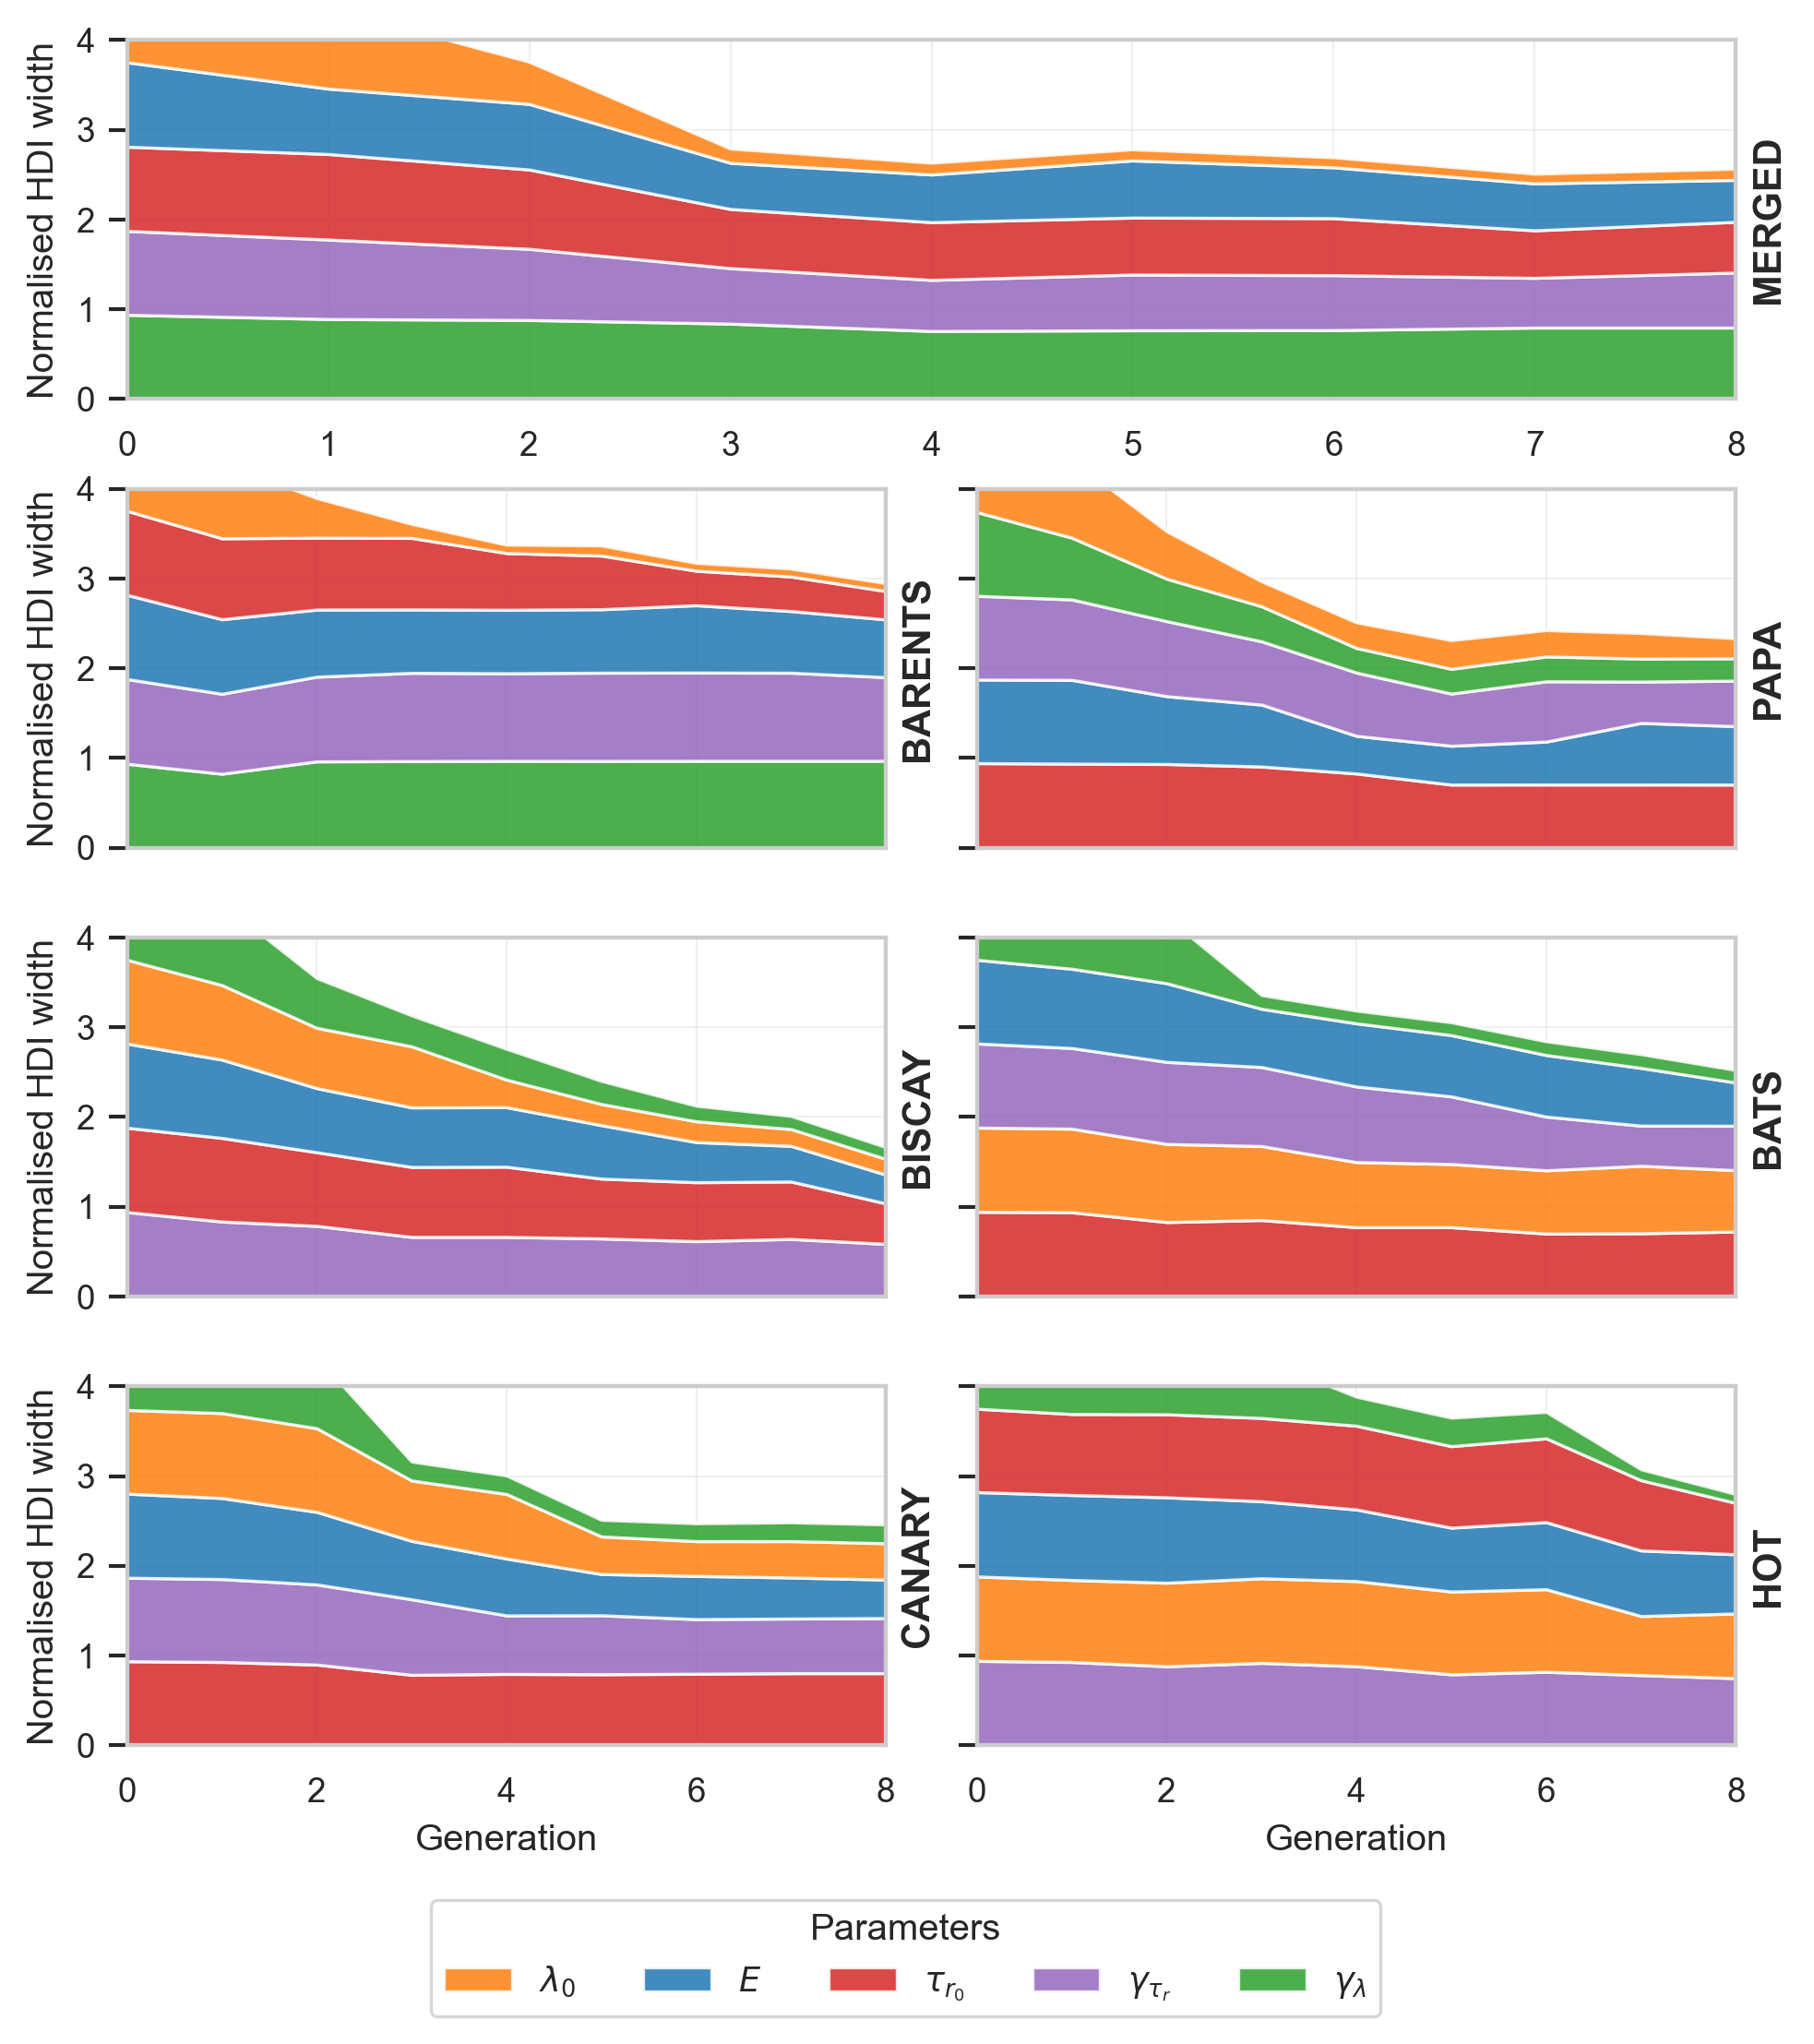

In [3]:
from matplotlib.gridspec import GridSpec

param_colors = {
    "energy_transfert":         "#1f77b4",
    "tr_0":                     "#d62728",
    "gamma_tr":                 "#9467bd",
    "lambda_temperature_0":     "#ff7f0e",
    "gamma_lambda_temperature": "#2ca02c",
}

# Layout: MERGED full width on row 0, then 2 columns of single-station experiments
station_order = ["MERGED", "BARENTS", "PAPA", "Bay_of_Biscay", "BATS", "Canaries", "HOT"]
station_order = [s for s in station_order if DISPLAY[s] in hdi_by_exp]
Y_LIMIT = 4  # sum of normalised HDI widths; max possible = number of parameters

fig = plt.figure(figsize=(7.5, 8), dpi=300)
gs = GridSpec(4, 2, figure=fig, hspace=0.25, wspace=0.12)
axes = [fig.add_subplot(gs[0, :])]                                          # MERGED full width
for i, sid in enumerate(station_order[1:]):
    row, col = (i // 2) + 1, i % 2
    axes.append(fig.add_subplot(gs[row, col]))

for ax, sid in zip(axes, station_order, strict=True):
    label = DISPLAY[sid]
    hdi = hdi_by_exp[label]
    # Stack parameters by descending final value (smallest reduction at the bottom)
    order_by_final = hdi.iloc[-1].sort_values(ascending=False).index.tolist()
    generations = hdi.index.values
    ax.stackplot(
        generations,
        *[hdi[p].values for p in order_by_final],
        labels=[PARAM_LABELS[p] for p in order_by_final],
        colors=[param_colors[p] for p in order_by_final],
        alpha=0.85,
    )
    ax.set_xlim(generations[0], generations[-1])
    ax.set_ylim(0, Y_LIMIT)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(label, fontsize=10, fontweight="bold")

# Y-label only on left column
for i, sid in enumerate(station_order):
    is_left = (sid == "MERGED") or ((i - 1) % 2 == 0)
    if is_left:
        axes[i].set_ylabel("Normalised HDI width")
    else:
        axes[i].set_yticklabels([])
# X-label only on bottom row
for i, sid in enumerate(station_order):
    if sid == "MERGED":
        continue
    row = (i - 1) // 2 + 1
    if row != 3:
        axes[i].set_xticklabels([])
    else:
        axes[i].set_xlabel("Generation")

# Legend (parameters), reversed to match visual stacking order (top-down)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], loc="lower center",
           bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True, title="Parameters")
plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIGURES_DIR / "Figure_8.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "Figure_8.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()